# Import Libraries :

In [89]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load Dataset :

In [90]:
import os
os.listdir("/kaggle/input")

['datasets']

In [91]:
os.listdir("/kaggle/input/datasets")

['razanihababdellatif']

In [92]:
os.listdir("/kaggle/input/datasets/razanihababdellatif")

['bank-marketing-and-customer-behavior-dataset']

In [93]:
df = pd.read_csv("/kaggle/input/datasets/razanihababdellatif/bank-marketing-and-customer-behavior-dataset/Bank_Marketing_Dataset.csv")

# 3. Data Understanding

Before cleaning the data, we first explore the dataset to understand its structure, dimensions, data types, and overall quality.


In [94]:
df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,Class
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,1
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,1
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,1
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,1
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,1


In [95]:
df.shape

(45211, 17)

In [96]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   V1      45211 non-null  int64 
 1   V2      45211 non-null  object
 2   V3      45211 non-null  object
 3   V4      45211 non-null  object
 4   V5      45211 non-null  object
 5   V6      45211 non-null  int64 
 6   V7      45211 non-null  object
 7   V8      45211 non-null  object
 8   V9      45211 non-null  object
 9   V10     45211 non-null  int64 
 10  V11     45211 non-null  object
 11  V12     45211 non-null  int64 
 12  V13     45211 non-null  int64 
 13  V14     45211 non-null  int64 
 14  V15     45211 non-null  int64 
 15  V16     45211 non-null  object
 16  Class   45211 non-null  int64 
dtypes: int64(8), object(9)
memory usage: 5.9+ MB


In [97]:
df.describe()

,V1,V6,V10,V12,V13,V14,V15,Class
count,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000,45211.000000
mean,40.936210,1362.272058,15.806419,258.163080,2.763841,40.197828,0.580323,1.116985
std,10.618762,3044.765829,8.322476,257.527812,3.098021,100.128746,2.303441,0.321406
min,18.000000,-8019.000000,1.000000,0.000000,1.000000,-1.000000,0.000000,1.000000
25%,33.000000,72.000000,8.000000,103.000000,1.000000,-1.000000,0.000000,1.000000
50%,39.000000,448.000000,16.000000,180.000000,2.000000,-1.000000,0.000000,1.000000
75%,48.000000,1428.000000,21.000000,319.000000,3.000000,-1.000000,0.000000,1.000000
max,95.000000,102127.000000,31.000000,4918.000000,63.000000,871.000000,275.000000,2.000000


In [98]:
df.columns

Index(['V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11',
       'V12', 'V13', 'V14', 'V15', 'V16', 'Class'],
      dtype='object')

# Rename Columns

Rename the dataset columns to meaningful names for easier understanding and analysis.

In [99]:
df.columns = [
    "age",
    "job",
    "marital",
    "education",
    "default",
    "balance",
    "housing",
    "loan",
    "contact",
    "day",
    "month",
    "duration",
    "campaign",
    "pdays",
    "previous",
    "poutcome",
    "subscribed"
]

In [100]:
df.columns

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'subscribed'],
      dtype='object')

# Data Quality Assessment

In this section, we evaluate the quality of the dataset before performing any cleaning operations. We check for missing values, duplicate records, data types, unique values, inconsistent categories, and potential outliers.

In [101]:
df.isnull().sum()

age           0
job           0
marital       0
education     0
default       0
balance       0
housing       0
loan          0
contact       0
day           0
month         0
duration      0
campaign      0
pdays         0
previous      0
poutcome      0
subscribed    0
dtype: int64

**Observation:**

No missing values were found in the dataset.

In [102]:
df.duplicated().sum()

np.int64(0)

**Observation:**

No duplicate records were found in the dataset.

In [103]:
df.dtypes

age            int64
job           object
marital       object
education     object
default       object
balance        int64
housing       object
loan          object
contact       object
day            int64
month         object
duration       int64
campaign       int64
pdays          int64
previous       int64
poutcome      object
subscribed     int64
dtype: object

**Observation:**

The data types are appropriate for their corresponding features.

In [104]:
df.nunique()

age             77
job             12
marital          3
education        4
default          2
balance       7168
housing          2
loan             2
contact          3
day             31
month           12
duration      1573
campaign        48
pdays          559
previous        41
poutcome         4
subscribed       2
dtype: int64

**Observation:**

The number of unique values in each column helps identify categorical and numerical features.

In [105]:
categorical_columns = [
    "job",
    "marital",
    "education",
    "default",
    "housing",
    "loan",
    "contact",
    "month",
    "poutcome",
    "subscribed"
]

for col in categorical_columns:
    print(f"\n{col.upper()}")
    print(df[col].unique())


JOB
['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']

MARITAL
['married' 'single' 'divorced']

EDUCATION
['tertiary' 'secondary' 'unknown' 'primary']

DEFAULT
['no' 'yes']

HOUSING
['yes' 'no']

LOAN
['no' 'yes']

CONTACT
['unknown' 'cellular' 'telephone']

MONTH
['may' 'jun' 'jul' 'aug' 'oct' 'nov' 'dec' 'jan' 'feb' 'mar' 'apr' 'sep']

POUTCOME
['unknown' 'failure' 'other' 'success']

SUBSCRIBED
[1 2]


In [106]:
# Check value counts and percentages of 'subscribed' column (before replacement)
print("--- Raw Value Counts ---")
print(df['subscribed'].value_counts())

print("\n--- Percentage Distribution ---")
print(df['subscribed'].value_counts(normalize=True) * 100)

--- Raw Value Counts ---
subscribed
1    39922
2     5289
Name: count, dtype: int64

--- Percentage Distribution ---
subscribed
1    88.30152
2    11.69848
Name: proportion, dtype: float64


In [107]:
df['subscribed'] = df['subscribed'].replace({2: 'No', 1: 'Yes'})

In [108]:
df["subscribed"].value_counts()

subscribed
Yes    39922
No      5289
Name: count, dtype: int64

### Detect Outliers

Visualize numerical features using boxplots to identify potential outliers before data cleaning.

In [109]:
numerical_columns = [
    "age",
    "balance",
    "duration",
    "campaign",
    "pdays",
    "previous"
]

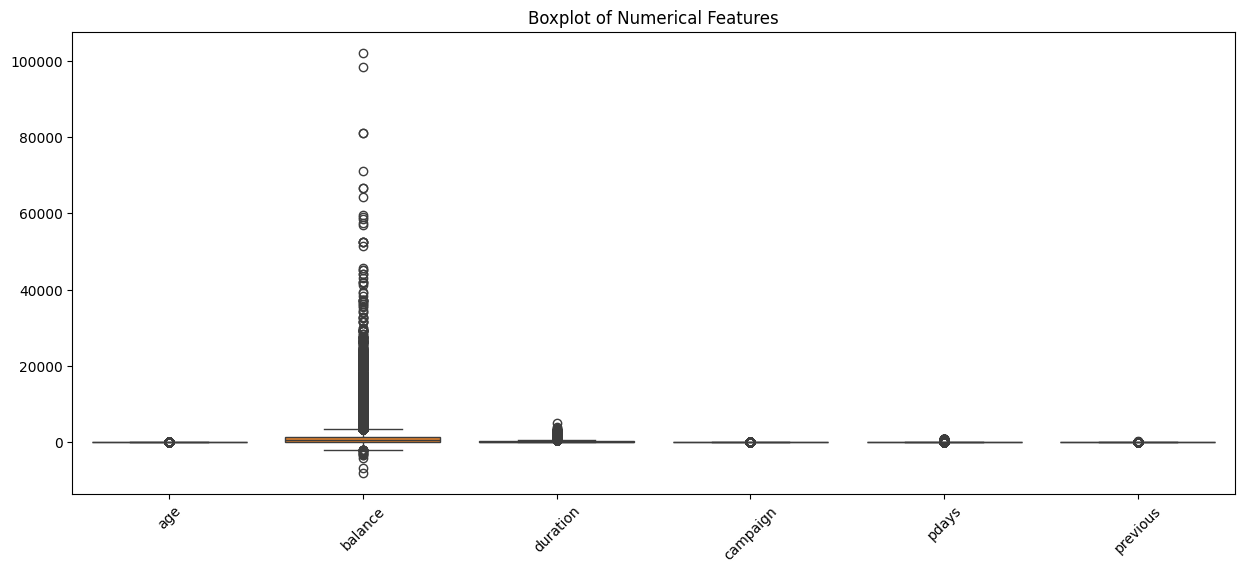

In [110]:
plt.figure(figsize=(15,6))

sns.boxplot(data=df[numerical_columns])

plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)

plt.show()

### Observation

The boxplots show the presence of outliers in several numerical features, particularly **balance**, **duration**, **campaign**, **pdays**, and **previous**.

These values appear to be valid business observations rather than data entry errors. Therefore, no outliers were removed from the dataset.

### Cleaning Summary 

- Column names were renamed for better readability.
- No missing values were found.
- No duplicate records were found.
- The target variable was converted from numeric labels to meaningful categories (Yes/No).
- Outliers were retained because they represent valid business observations.

### Handling "unknown" Values
In this step, we address categorical features containing "unknown" entries:
- **`job` and `education`**: The number of "unknown" records is very small. We replace "unknown" with the **Mode** (most frequent category) of each respective column to retain these observations without introducing substantial bias.
- **`contact` and `poutcome`**: "unknown" occurs at a very high frequency and carries specific business meaning (e.g., missing previous campaign history). Therefore, we keep "unknown" as a distinct category for these features.

In [111]:
# Mode Imputation for 'job' and 'education'
df['job'] = df['job'].replace('unknown', df['job'].mode()[0])
df['education'] = df['education'].replace('unknown', df['education'].mode()[0])

# Verify that 'unknown' has been replaced in job & education
print("Remaining 'unknown' in job:", (df['job'] == 'unknown').sum())
print("Remaining 'unknown' in education:", (df['education'] == 'unknown').sum())

Remaining 'unknown' in job: 0
Remaining 'unknown' in education: 0


### Encoding Categorical Features
To prepare the dataset for machine learning models:
1. The target variable (`subscribed`) is mapped to binary numeric values (`Yes` -> 1, `No` -> 0).
2. Predictor variables (`X`) are encoded using **One-Hot Encoding** (`pd.get_dummies`) to transform categorical strings into numeric representations while avoiding dummy variable trap (`drop_first=True`).

In [112]:
# 1. Separate features (X) and target variable (y)
X = df.drop(columns=['subscribed'])

# Convert target variable to binary numeric (1 / 0)
y = df['subscribed'].map({'Yes': 1, 'No': 0})

# 2. One-Hot Encoding for categorical predictor features
X_encoded = pd.get_dummies(X, drop_first=True)

# Output shape verification
print("Encoded Features Shape:", X_encoded.shape)
X_encoded.head()

Encoded Features Shape: (45211, 40)


,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jul,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,False,True,False,False,False,False,False,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,False,True,False,False,False,False,False,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True
4,33,1,5,198,1,-1,0,True,False,False,...,False,False,False,True,False,False,False,False,False,True


## Exploratory Data Analysis (EDA)

### Distribution of the Target Variable (`subscribed`)
In this section, we analyze the class distribution of our target variable `subscribed` to evaluate class balance.

In [113]:
import plotly.express as px
fig = px.pie(
    df, 
    names='subscribed', 
    title="Distribution of Target Variable (subscribed)", 
    color='subscribed', 
    hole=0.4, 
    color_discrete_map={'Yes': '#0A2947', 'No': '#8B5E3C'}
)

fig.update_traces(textinfo='percent+label')
fig.show()

*Interpretation:*
The doughnut chart displays a severe class imbalance within the target variable subscribed. The vast majority of clients (88.3%) are categorized as subscribed (Yes), whereas only 11.7% are non-subscribers (No). This heavy imbalance highlights that evaluating model performance using accuracy alone would be misleading, necessitating the use of metrics such as Precision, Recall, F1-Score, and ROC-AUC.

In [114]:
import plotly.subplots as sp
import plotly.graph_objects as go

fig = sp.make_subplots(
    rows=1, cols=3, 
    subplot_titles=("Subscription by Job", "Subscription by Marital Status", "Subscription by Education"),
    shared_yaxes=False
)

features = ['job', 'marital', 'education']

for i, feature in enumerate(features, 1):
    # Calculate counts and total per group for percentage calculation
    group_df = df.groupby([feature, 'subscribed']).size().reset_index(name='count')
    totals = group_df.groupby(feature)['count'].transform('sum')
    group_df['percentage'] = (group_df['count'] / totals * 100).round(1)

    for sub, color in zip(['Yes', 'No'], ['#0A2947', '#8B5E3C']):
        subset = group_df[group_df['subscribed'] == sub]
        
        fig.add_trace(
            go.Bar(
                x=subset[feature], 
                y=subset['count'], 
                name=sub, 
                marker_color=color, 
                showlegend=(i == 1 and sub == 'Yes'),
             
                hovertemplate=f"<b>{feature.capitalize()}:</b> %{{x}}<br>" +
                              f"<b>Subscribed ({sub}):</b> %{{y:,}} (%{{customdata}}%)<extra></extra>",
                customdata=subset['percentage']
            ),
            row=1, col=i
        )

fig.update_layout(
    title_text="Subscription Rates Across Categorical Features (Job, Marital, Education)",
    barmode='stack',
    height=500
)

fig.show()

*Interpretation:*
Job: Management, technician, and blue-collar roles account for the highest total contact volume. However, student and retired groups display the lowest overall subscription volume relative to their size.

Marital Status: Married individuals constitute the largest proportion of subscribers, while single and divorced clients show lower subscription counts.

Education: Clients with secondary and tertiary education form the primary base of term deposit subscribers, indicating that higher education correlates with greater product adoption.

In [115]:
import plotly.graph_objects as go
import numpy as np
from scipy.stats import gaussian_kde

duration_min_no = df[df['subscribed'] == 'Yes']['duration'] / 60
duration_min_yes = df[df['subscribed'] == 'No']['duration'] / 60

x_range_min = np.linspace(0, 25, 500)

kde_no = gaussian_kde(duration_min_no)(x_range_min)
kde_yes = gaussian_kde(duration_min_yes)(x_range_min)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=x_range_min, y=kde_no,
    mode='lines',
    fill='tozeroy',
    name='Yes',
    line=dict(color='#0A2947'),
    fillcolor='rgba(10, 41, 71, 0.35)'
))

fig.add_trace(go.Scatter(
    x=x_range_min, y=kde_yes,
    mode='lines',
    fill='tozeroy',
    name='No',
    line=dict(color='#8B5E3C'),
    fillcolor='rgba(139, 94, 60, 0.45)'
))

fig.update_layout(
    title="Smooth Call Duration Density (in Minutes)",
    xaxis_title="Call Duration (Minutes)",
    yaxis_title="Density",
    height=450,
    hovermode="x unified"
)

fig.update_xaxes(range=[0, 25])

fig.show()

## Insights from Call Duration Density Plot (in Minutes):
Non-Subscribers (No): Unsuccessful calls (No) show a much broader distribution and lower density peak across longer durations (extending up to 15–20 minutes).

Subscribers (Yes): Successful subscription calls (Yes) are heavily concentrated in shorter timeframes, peaking sharply around 2 to 2.5 minutes before rapidly declining.

Key Takeaway: Shorter call durations strongly correlate with successful term deposit subscriptions, whereas drawn-out conversations typically indicate non-converting clients.

In [116]:
import plotly.express as px

numeric_cols = ['age', 'balance', 'day', 'duration', 'campaign', 'pdays', 'previous']
df_corr = df[numeric_cols].copy()

df_corr['subscribed_num'] = df['subscribed'].map({'Yes': 1, 'No': 0})

corr_matrix = df_corr.corr().round(2)

fig = px.imshow(
    corr_matrix, 
    text_auto=True,
    aspect="auto", 
    title="Correlation Heatmap of Numeric Features",
    color_continuous_scale=['#8B5E3C', '#F3E4C9', '#0A2947'] )
fig.update_layout(height=500)
fig.show()

### 💡 Insights from Correlation Heatmap:
* **Call Duration:** Demonstrates the strongest positive correlation with `subscribed` ($r = 0.39$) among all numerical features, confirming that longer phone conversations directly drive higher customer acquisition rates.
* **Pdays & Previous:** Show a moderate positive correlation ($r = 0.45$), indicating that clients contacted in previous campaigns naturally accumulate higher past contact counts.
* **Weak Linear Relationships:** Demographic metrics like `age` and `balance` exhibit minimal linear correlation with the subscription outcome, highlighting that customer behavior during the campaign is far more predictive than demographic profile alone.

In [117]:
import plotly.express as px

month_order = ['jan', 'feb', 'mar', 'apr', 'may', 'jun', 'jul', 'aug', 'sep', 'oct', 'nov', 'dec']

df_month = df.groupby('month')['subscribed'].value_counts().unstack().fillna(0)
df_month = df_month.reindex(month_order).dropna()

df_month['Total_Calls'] = df_month['No'] + df_month['Yes']
df_month['Subscription_Rate (%)'] = (df_month['No'] / df_month['Total_Calls'] * 100).round(1)
df_month = df_month.reset_index()

fig = px.bar(
    df_month, 
    x='month', 
    y='Subscription_Rate (%)',
    text='Subscription_Rate (%)',
    title="Monthly Term Deposit Subscription Rate (%)",
    labels={'month': 'Month', 'Subscription_Rate (%)': 'Subscription Rate (%)'},
    color_discrete_sequence=['#0A2947'] 
)

fig.update_traces(texttemplate='%{text}%', textposition='outside')
fig.update_layout(
    height=450, 
    yaxis_range=[0, df_month['Subscription_Rate (%)'].max() + 10]
)
fig.show()

### 💡 Insights from Monthly Subscription Rate:
* **High Conversion Off-Peak Months:** March, September, October, and December achieve the highest subscription rates (often exceeding 40%–50%), despite having relatively low overall call volumes.
* **Volume vs. Conversion Efficiency:** May records the highest overall contact volume but yields one of the lowest subscription rates (~6.7%), indicating potential campaign fatigue or mass-marketing inefficiency.
* **Strategic Recommendation:** Marketing efforts should be reallocated toward targeted outreach during high-converting months (Mar, Sep, Oct, Dec) rather than high-volume, low-yield periods.

## Data Preprocessing for Machine Learning
  Before building machine learning models, the dataset must be prepared by encoding categorical variables, separating the features from the target variable, and splitting the data into training and testing sets.

## Encoding Categorical Variables
Machine learning algorithms require numerical input. Therefore, categorical variables are converted into numerical values using one-hot encoding.

In [118]:
df_ml = df.copy()

df_ml = pd.get_dummies(df_ml, drop_first=True)

df_ml.head()

,age,balance,day,duration,campaign,pdays,previous,job_blue-collar,job_entrepreneur,job_housemaid,...,month_jun,month_mar,month_may,month_nov,month_oct,month_sep,poutcome_other,poutcome_success,poutcome_unknown,subscribed_Yes
0,58,2143,5,261,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
1,44,29,5,151,1,-1,0,False,False,False,...,False,False,True,False,False,False,False,False,True,True
2,33,2,5,76,1,-1,0,False,True,False,...,False,False,True,False,False,False,False,False,True,True
3,47,1506,5,92,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,True,True
4,33,1,5,198,1,-1,0,True,False,False,...,False,False,True,False,False,False,False,False,True,True


### One-Hot Encoding
Categorical variables were converted into numerical columns using one-hot encoding. This prepares the dataset for machine learning models that require numerical input.

### Feature and Target Separation
The independent variables (features) are separated from the target variable before training the models.

In [119]:
X = df_ml.drop("subscribed_Yes", axis=1)
y = df_ml["subscribed_Yes"]

print(X.shape)
print(y.shape)

(45211, 40)
(45211,)


### Train-Test Split
The dataset is divided into training and testing sets. The training set is used to build the models, while the testing set is used to evaluate their performance.

In [120]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(36168, 40)
(9043, 40)


### Train-Test Split
The dataset was split into training and testing sets. The training set is used to train the model, while the testing set is used to evaluate its performance.

# 7. Model Building
In this section, machine learning models are trained to predict whether a customer will subscribe to a term deposit based on customer and campaign-related features.

Two classification models are used:

Logistic Regression
Random Forest Classifier

### Logistic Regression
Logistic Regression is a widely used classification algorithm that estimates the probability of a binary outcome. It serves as a simple and effective baseline model for customer subscription prediction.

In [121]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# 1. Initialize and fit the scaler on training data, then transform
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)  # Apply the same scaling to test data

# 2. Train the model on the scaled data
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

### Logistic Regression Training
The numerical features were standardized using StandardScaler before training. Then, a Logistic Regression model was trained on the scaled training data to predict customer subscriptions.

In [122]:
# Make predictions on the scaled test set
y_pred_log = log_model.predict(X_test_scaled)

# View the first 10 predictions
y_pred_log[:10]

array([ True, False,  True,  True,  True,  True,  True,  True,  True,
        True])

### Model Prediction
The trained Logistic Regression model was used to make predictions on the test dataset. The first 10 predicted values were displayed to verify that the model generated predictions successfully.

# 8. Logistic Regression Evaluation
The performance of the Logistic Regression model is evaluated using multiple classification metrics.

In [123]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_log))
print("Precision:", precision_score(y_test, y_pred_log))
print("Recall   :", recall_score(y_test, y_pred_log))
print("F1 Score :", f1_score(y_test, y_pred_log))
print("ROC AUC  :", roc_auc_score(y_test, y_pred_log))

Accuracy : 0.9020236647130377
Precision: 0.9174409032106315
Recall   : 0.9769567939887289
F1 Score : 0.9462639495390587
ROC AUC  : 0.6567203629678995


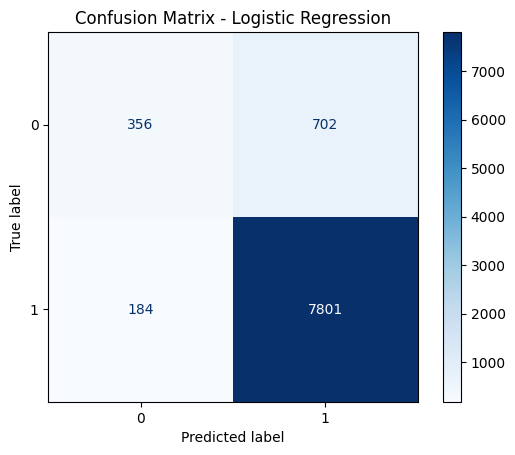

In [124]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred_log)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues")

plt.title("Confusion Matrix - Logistic Regression")

plt.show()

### Interpretation
The confusion matrix shows how well the Logistic Regression model classified the test data. Most predictions are correct, while the incorrect predictions represent the model's classification errors.

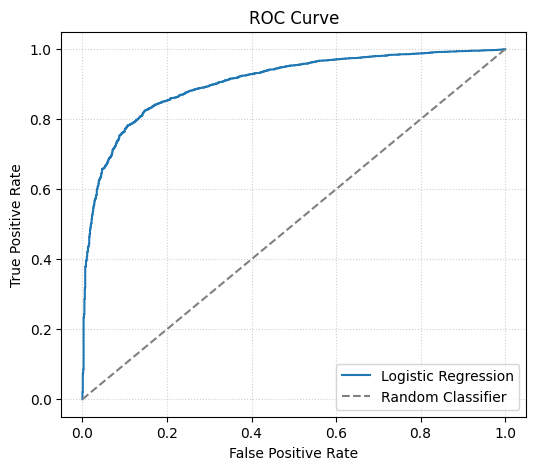

In [125]:
from sklearn.metrics import roc_curve
import matplotlib.pyplot as plt

# 1. Get predicted probabilities using SCALED test data
y_prob_log = log_model.predict_proba(X_test_scaled)[:, 1]

# 2. Compute ROC curve values
fpr, tpr, thresholds = roc_curve(y_test, y_prob_log)

# 3. Plot ROC Curve
plt.figure(figsize=(6, 5))

plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot([0, 1], [0, 1], "--", color="gray", label="Random Classifier")  # Visual reference line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True, linestyle=":", alpha=0.6)  # Optional: adds gridlines for better readability

plt.show()

### Interpretation
The ROC curve shows the ability of the Logistic Regression model to distinguish between the two classes. A curve closer to the top-left corner indicates better classification performance.

# 9. Random Forest Classifier
Random Forest is an ensemble learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

In [126]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

### Random Forest Training
A Random Forest classifier was trained using the training dataset. The model learns from multiple decision trees to improve prediction accuracy and reduce overfitting.

In [127]:
y_pred_rf = rf_model.predict(X_test)

y_prob_rf = rf_model.predict_proba(X_test)[:,1]

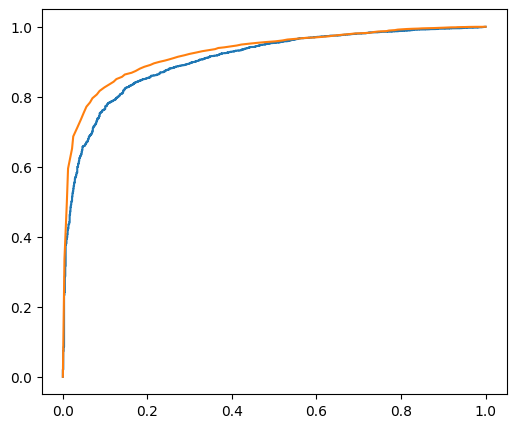

In [128]:
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label="Logistic Regression")
plt.plot(fpr_rf, tpr_rf, label="Random Forest")

### Interpretation
The ROC curves compare the performance of the Logistic Regression and Random Forest models. The model with the curve closer to the top-left corner has better classification performance.

# 10. Random Forest Evaluation
The Random Forest model is evaluated using multiple classification metrics to measure its predictive performance.

In [129]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

print("Accuracy :", accuracy_score(y_test, y_pred_rf))
print("Precision:", precision_score(y_test, y_pred_rf))
print("Recall   :", recall_score(y_test, y_pred_rf))
print("F1 Score :", f1_score(y_test, y_pred_rf))
print("ROC AUC  :", roc_auc_score(y_test, y_prob_rf))

Accuracy : 0.9034612407386929
Precision: 0.9248506571087216
Recall   : 0.96944270507201
F1 Score : 0.9466218281870987
ROC AUC  : 0.9282193219091089


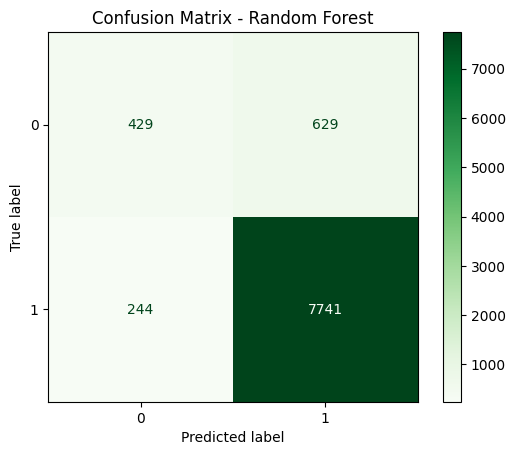

In [130]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(confusion_matrix=cm_rf)

disp.plot(cmap="Greens")

plt.title("Confusion Matrix - Random Forest")

plt.show()

### Interpretation
The confusion matrix shows how well the Random Forest model classified the test data. A higher number of correct predictions and fewer misclassifications indicate better model performance.

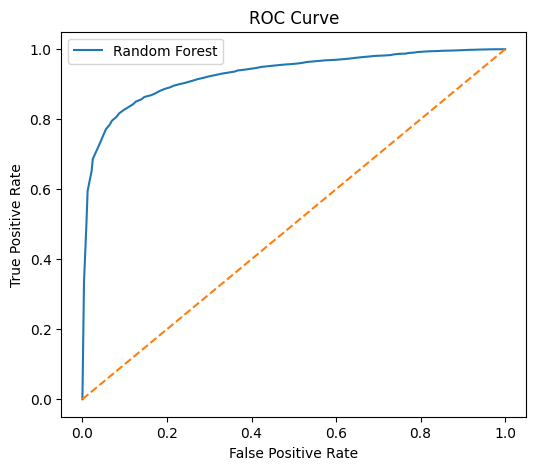

In [131]:
fpr_rf, tpr_rf, thresholds_rf = roc_curve(y_test, y_prob_rf)

plt.figure(figsize=(6,5))

plt.plot(fpr_rf, tpr_rf, label="Random Forest")
plt.plot([0,1],[0,1],"--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()

plt.show()

### Interpretation
The ROC curve shows how well the Random Forest model distinguishes between the two classes. A curve closer to the top-left corner indicates better classification performance.

# 11. Model Comparison
The performance of the Logistic Regression and Random Forest models is compared using the evaluation metrics.

In [132]:
comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Random Forest"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_log),
        accuracy_score(y_test, y_pred_rf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_log),
        precision_score(y_test, y_pred_rf)
    ],
    "Recall": [
        recall_score(y_test, y_pred_log),
        recall_score(y_test, y_pred_rf)
    ],
    "F1 Score": [
        f1_score(y_test, y_pred_log),
        f1_score(y_test, y_pred_rf)
    ],
    "ROC AUC": [
        roc_auc_score(y_test, y_prob_log),
        roc_auc_score(y_test, y_prob_rf)
    ]
})

comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.902024,0.917441,0.976957,0.946264,0.906856
1,Random Forest,0.903461,0.924851,0.969443,0.946622,0.928219


# 12. Feature Importance
Feature importance identifies the variables that contribute the most to the Random Forest model's predictions.

In [133]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance.head(10)

,Feature,Importance
3,duration,0.276958
1,balance,0.102290
0,age,0.098493
2,day,0.087708
38,poutcome_success,0.055466
5,pdays,0.041127
4,campaign,0.040015
6,previous,0.020404
22,housing_yes,0.020252
32,month_mar,0.015071


### Feature Importance
The importance scores of all features were calculated using the trained Random Forest model. The features were then sorted in descending order to identify the top 10 most influential predictors.

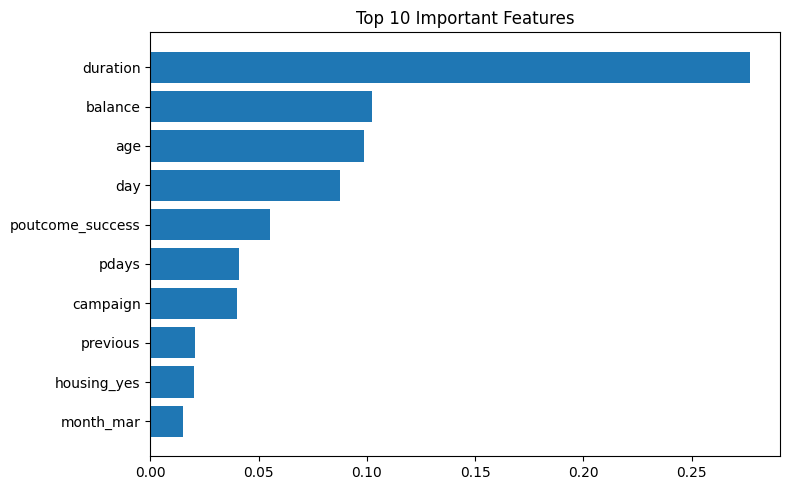

In [134]:
top10 = importance.head(10)

plt.figure(figsize=(8,5))

plt.barh(
    top10["Feature"],
    top10["Importance"]
)

plt.gca().invert_yaxis()

plt.title("Top 10 Important Features")

plt.tight_layout()

plt.show()

### Interpretation
The bar chart displays the 10 most important features identified by the Random Forest model. Features with higher importance values contribute more to the model's predictions.

# 13. Recommendation
Based on the analysis and machine learning results:

Focus marketing campaigns on customer groups with higher subscription likelihood.
Give special attention to important features such as call duration and previous campaign outcome.
Use the better-performing model to support customer targeting and improve campaign efficiency.

# 4. Conclusion
This project analyzed customer behavior using data preprocessing, exploratory data analysis, and machine learning techniques.

Two classification models were developed and evaluated to predict customer subscription behavior. The comparison showed that machine learning can effectively support marketing decisions by identifying customers with a higher probability of subscribing to a term deposit.

The insights obtained from this project can help banks optimize marketing campaigns, improve customer targeting, and increase overall campaign success